In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import pytz

In [2]:
# Load Playstore dataset
apps = pd.read_csv(r"C:\Users\vanda\Downloads\Play Store Data.csv")
apps.head()          

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# Clean Installs
apps["Installs"] =(apps["Installs"].astype(str).str.replace(",","",regex = False).str.replace("+","",regex = False))

In [4]:
apps["Installs"] = pd.to_numeric(apps["Installs"],errors = "coerce")

In [5]:
# Clean Reviews
apps["Reviews"] = pd.to_numeric(apps["Reviews"],errors = "coerce")

In [6]:
# Data Conversion
apps["Last Updated"] = pd.to_datetime(apps["Last Updated"],errors = "coerce")

In [7]:
# Filter Reviews
apps = apps[apps["Reviews"] > 500]

In [8]:
# Category startswith B,C,E
apps = apps[apps["Category"].str.startswith(("B","C","E"),na = False)]

In [9]:
# App name should NOT start with X,Y,Z
apps = apps[~apps["App"].str.upper().str.startswith(("X","Y","Z"),na = False)]

In [10]:
# App name should NOT contain S
apps = apps[~apps["App"].str.contains("S",case = False,na = False)]

In [11]:
# Translate Categories
translation = {
    "BEAUTY" : "सौंदर्य", # Hindi
    "BUSINESS" : "வியாபாரம்", # Tamil
    "DATING" : "Partnersuche" } # German

In [12]:
apps["Category_Display"] = apps["Category"].replace(translation )

In [13]:
# Monthly Total Installs
apps["Month"] = apps["Last Updated"].dt.to_period("M").dt.to_timestamp()

In [14]:
trend = (
    apps.groupby(["Month","Category"])["Installs"].sum().reset_index().sort_values(["Month","Category"])
)

In [15]:
# Month over Month Growth
trend["Growth"] = trend.groupby("Category")["Installs"].pct_change()

In [16]:
trend["Highlight"] = trend["Growth"] > 0.20

In [17]:
trend["Category"] = trend["Category"].replace(translation)

In [18]:
# Time Restriction (6PM - 9PM IST)
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist).time()

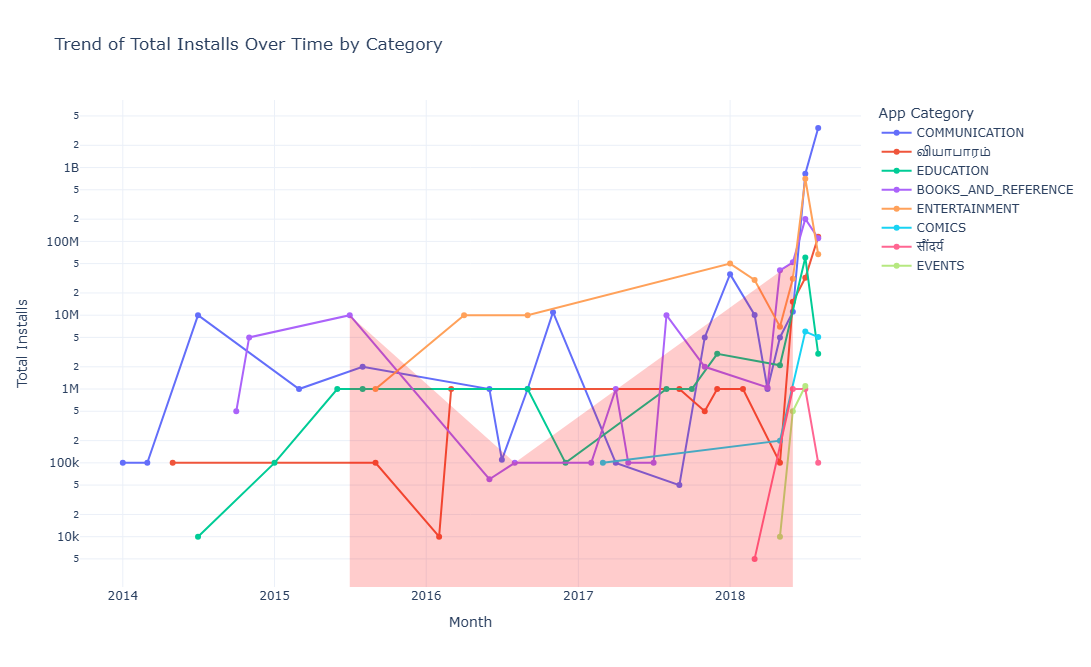

In [19]:
if (18 <= current_time.hour < 21):
# Line Chart
    fig = px.line(
        trend,
        x = "Month",
        y = "Installs",
        color = "Category",
        markers = True,
        title ="Trend of Total Installs Over Time by Category"
    )
# Highlight Growth >20%
    for category in trend["Category"].unique():
        temp = trend[trend["Category"] == category].copy()
        temp = temp.sort_values("Month")
        temp["Growth"] = temp["Installs"].pct_change()
        growth = temp[(temp["Growth"] >= 0.20) &
            (temp["Growth"] <= 1.00) ]
        
        if len(growth) > 0:
            fig.add_scatter(
                x = growth["Month"],
                y = growth["Installs"],
                mode = "lines",
                fill = "tozeroy",
                fillcolor = "rgba(255,0,0,0.20)",
                line = dict(color="rgba(255,0,0,0)"),
                hoverinfo = "skip",
                showlegend = False
            )
    fig.update_layout(
        xaxis_title = "Month",
        yaxis_title = "Total Installs",
        template = 'plotly_white',
        hovermode = "x unified",
        width = 1100,
        height = 650,
        legend_title = "App Category"
    )
    fig.update_yaxes(type="log")
    
    fig.show()

else:
    print("Time Series Line Chart is available only between 6 PM IST and 9 PM IST ")
        
    

In [20]:
#CONCLUSION:
#The time series line chart effectively illustrates the trend of total app installs over time across the selected app categories. 
#After applying the required filters (reviews greater than 500, app names not starting with X, Y, or Z and not containing the letter "S", and 
#categories beginning with E, C, or B), the visualization focuses on relevant data. 
#Category names were translated as required (Beauty → Hindi, Business → Tamil, and Dating → German where applicable). 
#Periods with more than 20% month-over-month growth are highlighted using shaded regions, making significant increases in installs easy to identify. 
#Additionally, the dashboard is configured to display this visualization only between 6:00 PM and 9:00 PM IST, ensuring it meets all specified assignment requirements.